# EDA de autos
## 1. Carga y estructura

In [1]:
import pandas as pd

df = pd.read_csv("data/autos.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [2]:
df.shape

(398, 9)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [4]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


## 2. Calidad de datos

In [5]:
df["horsepower"].isna().sum()

np.int64(6)

In [6]:
df_limpio = df.dropna(subset=["horsepower"])
df_limpio.shape

(392, 9)

In [7]:
df_limpio.to_csv("data/autos_limpio.csv", index=False)

In [8]:
df_limpio["horsepower"].isna().sum()

np.int64(0)

## 3. Análisis de mpg

In [9]:
mpg_promedio = df_limpio["mpg"].mean()
mpg_mediano = df_limpio["mpg"].median()

mpg_promedio, mpg_mediano

(np.float64(23.445918367346938), np.float64(22.75))

In [10]:
round(mpg_promedio, 2), round(mpg_mediano, 2)

(np.float64(23.45), np.float64(22.75))

## 4. Relación entre variables

In [11]:
correlacion_weight_mpg = df_limpio["weight"].corr(df_limpio["mpg"])
round(correlacion_weight_mpg, 4)

np.float64(-0.8322)

In [12]:
mpg_por_origen = df_limpio.groupby("origin")["mpg"].mean()
mpg_por_origen

origin
europe    27.602941
japan     30.450633
usa       20.033469
Name: mpg, dtype: float64

In [13]:
origen_mas_eficiente = mpg_por_origen.idxmax()
origen_mas_eficiente

'japan'

## 5. Gráficos

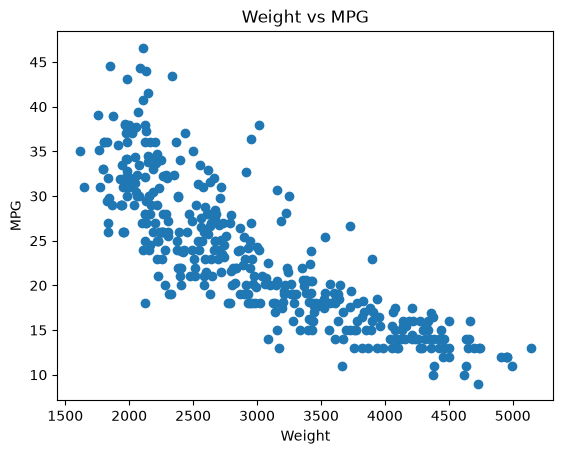

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_limpio["weight"], df_limpio["mpg"])
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Weight vs MPG")
plt.savefig("resultados/figuras/scatter_weight_mpg.png", bbox_inches="tight")
plt.show()

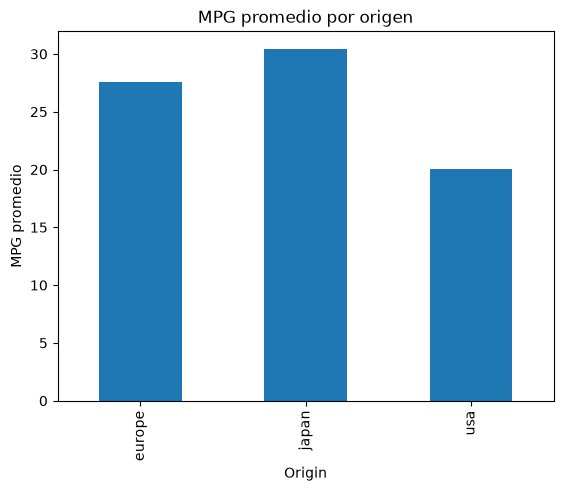

In [15]:
mpg_por_origen.plot(kind="bar")
plt.ylabel("MPG promedio")
plt.xlabel("Origin")
plt.title("MPG promedio por origen")
plt.savefig("resultados/figuras/mpg_por_origen.png", bbox_inches="tight")
plt.show()

In [16]:
import os

os.listdir("resultados/figuras")

['mpg_por_origen.png', 'scatter_weight_mpg.png']